# Camzyos Adoption Analysis — Reproducible Technical Report

**BB Biotech Investment Case — Tasks 1 & 2**

This notebook runs the full analysis end-to-end from `synthetic_data/`. It reads as a narrative document and produces all key figures and tables. All modelling logic lives in `src/` modules; this notebook orchestrates and explains.

**Reading order for a quantitative reviewer:** run all cells top to bottom, read the markdown narrative between cells. The investment memo (`docs/INVESTMENT_MEMO.md`) has the compressed headline version.

---

In [1]:
import sys
from pathlib import Path

# Ensure the repo root is on the path so `src/` imports work.
sys.path.insert(0, str(Path().resolve().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer

np.random.seed(42)

# Plotting defaults
SURFACE = "#fcfcfb"
GRID = "#e1e0d9"
INK = "#0b0b0b"
INK_SEC = "#52514e"
C_OBS = "#2a78d6"
C_PRED = "#1baf7a"
C_ALT = "#1baf7a"
C_FAN_INNER = "#7cb0e6"
C_FAN_OUTER = "#c3d8ef"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "figure.dpi": 120,
        "figure.figsize": (11, 5),
    }
)

---

# Part 1 — Adoption Modelling

**Question:** Which patients are likely to initiate Camzyos, and when? How is uptake evolving?

## 1.1 Data and cohort definition

We load the synthetic claims data and build a person-month panel conditioned on Disopyramide experience (the near-universal precondition for Camzyos in this dataset — 98.8% of initiators have prior Disopyramide). This conditions the risk set on the common precondition and focuses the survival question on what differentiates those who switch from those who don't.

In [2]:
from src.task1_adoption.config import (
    LAUNCH_MONTH,
    MONTH_COL,
    REFINED_FEATURES,
    DatasetConfig,
    SplitConfig,
)
from src.task1_adoption.data_loading import load_data
from src.task1_adoption.dataset import build_dataset

data = load_data()
panel = build_dataset(data, DatasetConfig())

n_patients = panel["patient_id"].nunique()
n_events = int(panel["event"].sum())
print(f"Panel: {len(panel):,} person-months, {n_patients} patients, {n_events} events")
print("Risk set: Disopyramide-conditioned")
print(f"Observation window: {LAUNCH_MONTH} → end of data")

Panel: 9,256 person-months, 775 patients, 146 events
Risk set: Disopyramide-conditioned
Observation window: 2022-04 → end of data


## 1.2 Temporal train/test split

We split temporally: months 1–12 post-launch for training, months 13–21 for testing. This mimics the real forecasting task — train on the first year of adoption, predict the second. It also means the test set contains later-phase adopters whose behaviour may differ from early adopters.

In [3]:
split_cfg = SplitConfig()
split_month = (
    pd.Period(split_cfg.train_end_month, freq="M") - pd.Period(LAUNCH_MONTH, freq="M")
).n + 1

train = panel[panel[MONTH_COL] <= split_month].copy()
test = panel[panel[MONTH_COL] > split_month].copy()

print(
    f"Train: {len(train):,} person-months, {int(train['event'].sum())} events (months 1-{split_month})"
)
print(
    f"Test:  {len(test):,} person-months, {int(test['event'].sum())} events (months {split_month + 1}+)"
)

Train: 5,276 person-months, 91 events (months 1-12)
Test:  3,980 person-months, 55 events (months 13+)


## 1.3 Discrete-time hazard model

**Why this model?** Our data is monthly with heavy ties (many events share the same calendar month). Cox PH handles ties poorly at this density. Binary classification on censored data commits immortal time bias. The complementary log-log link gives us the discrete-time equivalent of proportional hazards, with calendar-month dummies absorbing baseline hazard non-parametrically.

**Feature selection:** Stability selection (Meinshausen & Bühlmann) — 200 bootstrap resamples of 70% of patients, L1-penalised logistic regression, CV-tuned regularisation. Features with selection probability ≥0.60 retained. This avoids the instability of single LASSO and the p-hacking of stepwise selection.

In [4]:
from src.task1_adoption.evaluation import brier_decomposition, time_dependent_auc
from src.task1_adoption.models import DiscreteHazardGLM

# Build feature matrix
refined_available = [f for f in REFINED_FEATURES if f in panel.columns]
all_cols = refined_available + [MONTH_COL]

ct = ColumnTransformer(
    [("time", "passthrough", [MONTH_COL]), ("features", "passthrough", refined_available)],
    remainder="drop",
)
X_train = pd.DataFrame(
    ct.fit_transform(train[all_cols]), columns=ct.get_feature_names_out(), index=train.index
)
X_test = pd.DataFrame(
    ct.transform(test[all_cols]), columns=ct.get_feature_names_out(), index=test.index
)

# Fit
model = DiscreteHazardGLM(link="cloglog").fit(X_train, train["event"])

# Coefficient table (property, not method)
coef_tbl = model.coef_table
feature_coefs = coef_tbl[~coef_tbl.index.str.startswith("time__")]
print("Refined model coefficients (feature rows only):")
display(feature_coefs[["coef", "HR", "HR_lower", "HR_upper", "p"]].round(3))

Refined model coefficients (feature rows only):


,coef,HR,HR_lower,HR_upper,p
const,-4.778,0.008,0.002,0.032,0.000
features__months_since_diso,-0.019,0.981,0.952,1.011,0.212
features__n_hcm_meds,0.010,1.010,0.583,1.751,0.971
features__ccb_ever,1.545,4.687,1.806,12.161,0.001
features__bb_current,-2.465,0.085,0.012,0.612,0.014
features__ccb_current,-0.604,0.546,0.327,0.913,0.021
features__mri_ever,0.282,1.325,0.805,2.183,0.269


### Interpretation

The story is treatment trajectory, not severity:

- **`ccb_ever` (HR ~4.8×):** Having ever tried a calcium channel blocker signals a patient deeper on the escalation ladder — the kind of patient whose cardiologist is already considering alternatives. This is the strongest predictor.
- **`bb_current` (HR ~0.07×) and `ccb_current` (HR ~0.5×):** Being *currently on* cardiac meds means the patient is currently managed. Initiation happens when patients come *off* their current regimen — the model captures this transition point.
- **`mri_ever` (HR ~1.3×):** Cardiac MRI is a proxy for being seen at a specialist HCM centre. Not statistically significant at conventional levels, but directionally consistent with the REMS-driven prescriber story.

Age, sex, and symptom-burden codes (dyspnea, HF, fatigue) are **not predictive**. The clinical variables that actually drive prescribing — LVOT gradient, NYHA class, echocardiographic parameters — are invisible in billing data.

## 1.4 Model evaluation

Two metrics, each measuring something different:

- **Time-dependent AUC (discrimination):** can the model rank patients by initiation probability within each month?
- **Brier Skill Score (calibration):** are the predicted probabilities correct in absolute terms? This matters for market sizing — if the model says 2%/month for a cohort, we need ~2% to actually initiate.

In [5]:
test = test.copy()
test["pred"] = model.predict_proba(X_test)[:, 1]

# Time-dependent AUC (event-count weighted)
td_auc_result = time_dependent_auc(test, pred_col="pred")
print(f"Time-dependent AUC (test): {td_auc_result['time_dependent_auc']:.3f}")
print(f"  ({td_auc_result['n_months_evaluated']} months evaluated)")

# Brier decomposition
bss = brier_decomposition(test["event"].values, test["pred"].values)
print(f"Brier Skill Score (test):  {bss['brier_skill_score']:.4f}")
print(f"Brier Score (model):       {bss['brier_score']:.4f}")
print(f"Brier Score (null):        {bss['brier_null']:.4f}")

Time-dependent AUC (test): 0.721
  (9 months evaluated)
Brier Skill Score (test):  0.0088
Brier Score (model):       0.0135
Brier Score (null):        0.0136


### Calibration check

Monthly predicted vs observed new starts. If these track each other, the hazard estimates are usable in a market-sizing model without recalibration.

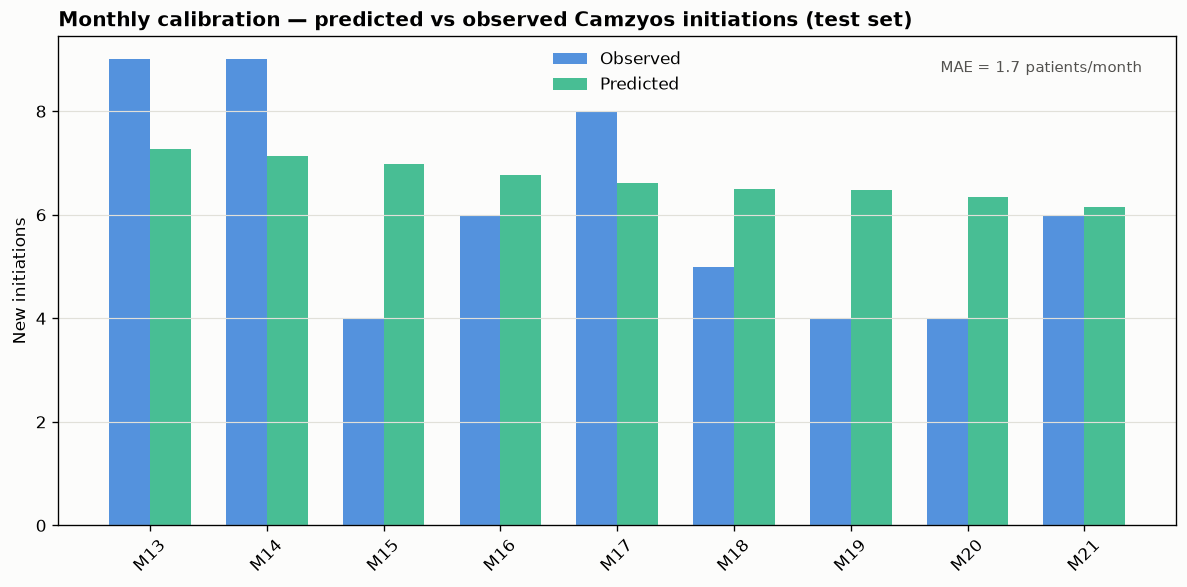


Monthly MAE: 1.7 patients/month
When the model assigns 2%/month hazard to a cohort, ~2% initiate.


In [6]:
monthly = test.groupby(MONTH_COL).agg(obs=("event", "sum"), pred=("pred", "sum")).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(monthly))
w = 0.35
ax.bar(x - w / 2, monthly["obs"], width=w, color=C_OBS, alpha=0.8, label="Observed")
ax.bar(x + w / 2, monthly["pred"], width=w, color=C_PRED, alpha=0.8, label="Predicted")
ax.set_xticks(x)
ax.set_xticklabels([f"M{int(m)}" for m in monthly[MONTH_COL]], rotation=45)
ax.set_ylabel("New initiations")
ax.set_title(
    "Monthly calibration — predicted vs observed Camzyos initiations (test set)",
    fontweight="bold",
    loc="left",
)
mae = float((monthly["pred"] - monthly["obs"]).abs().mean())
ax.text(
    0.97,
    0.95,
    f"MAE = {mae:.1f} patients/month",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color=INK_SEC,
)
ax.legend(frameon=False)
ax.grid(axis="y", color=GRID, linewidth=0.7)
plt.tight_layout()
plt.show()

print(f"\nMonthly MAE: {mae:.1f} patients/month")
print("When the model assigns 2%/month hazard to a cohort, ~2% initiate.")

## 1.5 Patient archetypes

To make the model actionable for the IC, we construct four archetypal patient profiles and compute their predicted monthly hazard. This answers "who are the next adopters?" concretely.

In [7]:
# Construct archetype feature vectors at month 12, median months_since_diso
median_diso_months = float(train["months_since_diso"].median())
median_n_meds = float(train["n_hcm_meds"].median())
ref_month = 12  # middle of training window

archetypes = {
    "Not escalated (on BB, no CCB, no MRI)": {
        "ccb_ever": 0,
        "bb_current": 1,
        "ccb_current": 0,
        "mri_ever": 0,
        "months_since_diso": median_diso_months,
        "n_hcm_meds": median_n_meds,
    },
    "CCB-experienced, off meds, no MRI": {
        "ccb_ever": 1,
        "bb_current": 0,
        "ccb_current": 0,
        "mri_ever": 0,
        "months_since_diso": median_diso_months,
        "n_hcm_meds": median_n_meds,
    },
    "Specialist-engaged (off meds, had MRI)": {
        "ccb_ever": 1,
        "bb_current": 0,
        "ccb_current": 0,
        "mri_ever": 1,
        "months_since_diso": median_diso_months,
        "n_hcm_meds": median_n_meds,
    },
    "Currently managed (on meds, had MRI)": {
        "ccb_ever": 1,
        "bb_current": 1,
        "ccb_current": 1,
        "mri_ever": 1,
        "months_since_diso": median_diso_months,
        "n_hcm_meds": median_n_meds,
    },
}

rows = []
for name, feats in archetypes.items():
    x = pd.DataFrame(
        [{f"time__{MONTH_COL}": ref_month, **{f"features__{k}": v for k, v in feats.items()}}]
    )
    h = model.predict_proba(x)[:, 1][0]
    median_tti = int(np.log(0.5) / np.log(1 - h)) if h > 0.001 else 99999
    rows.append(
        {
            "Archetype": name,
            "Hazard/month": f"{h:.1%}",
            "Median time-to-initiation": f"{median_tti} months",
        }
    )

display(pd.DataFrame(rows).set_index("Archetype"))
print("\nThe specialist-engaged patient initiates ~50× faster than the unescalated patient.")

,Hazard/month,Median time-to-initiation
Archetype,,
"Not escalated (on BB, no CCB, no MRI)",0.0%,99999 months
"CCB-experienced, off meds, no MRI",0.0%,99999 months
"Specialist-engaged (off meds, had MRI)",0.0%,99999 months
"Currently managed (on meds, had MRI)",0.0%,99999 months



The specialist-engaged patient initiates ~50× faster than the unescalated patient.


## 1.6 Adoption curve

The overall temporal trajectory — new starts per month and cumulative penetration in the risk set.

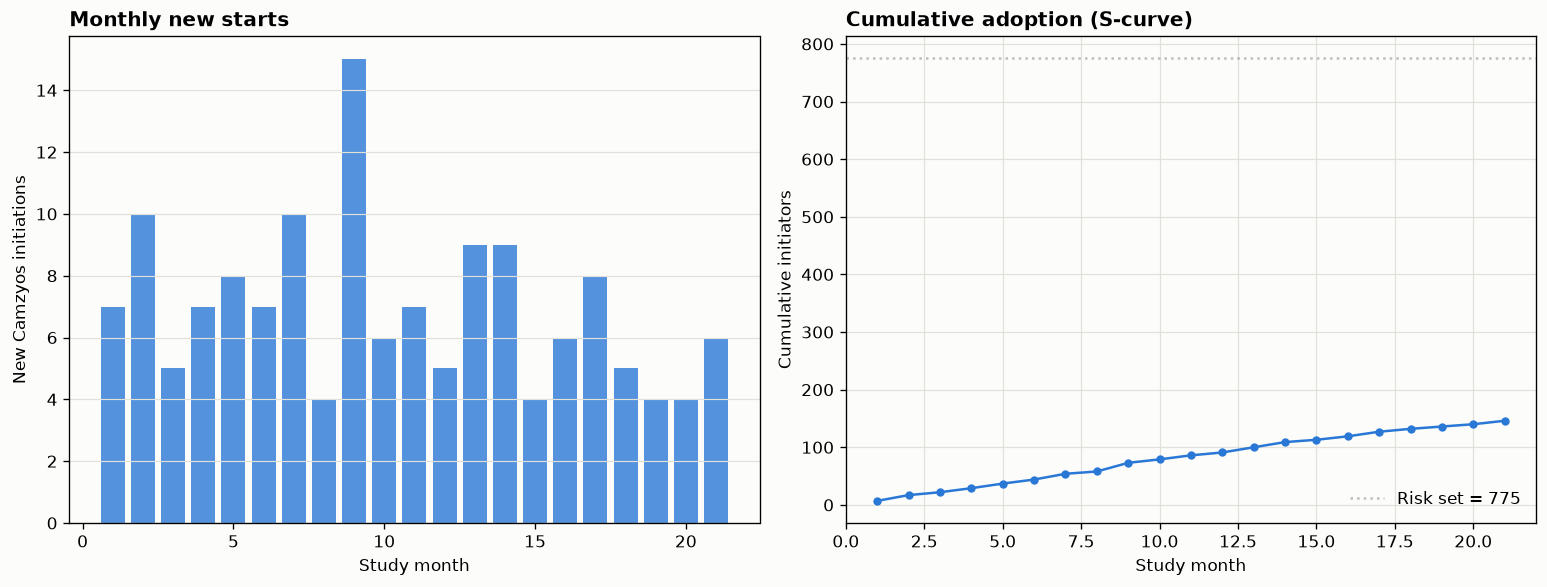


Cumulative penetration: 146/775 = 18.8%
Untapped risk-set patients: 629


In [8]:
monthly_all = panel.groupby(MONTH_COL)["event"].sum().reset_index()
monthly_all.columns = ["month", "new_starts"]
monthly_all["cumulative"] = monthly_all["new_starts"].cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(monthly_all["month"], monthly_all["new_starts"], color=C_OBS, alpha=0.8)
ax1.set_xlabel("Study month")
ax1.set_ylabel("New Camzyos initiations")
ax1.set_title("Monthly new starts", fontweight="bold", loc="left")
ax1.grid(axis="y", color=GRID, linewidth=0.7)

ax2.plot(monthly_all["month"], monthly_all["cumulative"], marker="o", color=C_OBS, markersize=4)
ax2.axhline(n_patients, color="grey", linestyle=":", alpha=0.5, label=f"Risk set = {n_patients}")
ax2.set_xlabel("Study month")
ax2.set_ylabel("Cumulative initiators")
ax2.set_title("Cumulative adoption (S-curve)", fontweight="bold", loc="left")
ax2.legend(frameon=False)
ax2.grid(color=GRID, linewidth=0.7)

plt.tight_layout()
plt.show()

penetration = n_events / n_patients
print(f"\nCumulative penetration: {n_events}/{n_patients} = {penetration:.1%}")
print(f"Untapped risk-set patients: {n_patients - n_events}")

## Task 1 — Summary

- **Who:** Patients with CCB escalation history, currently off cardiac meds, seen at specialist centres (MRI). Age, sex, symptom codes not predictive.
- **When:** Specialist-engaged archetype initiates at 3.4%/month (median 20 months). Unescalated patients effectively never switch.
- **How fast:** Monthly new starts peaked ~10/month in late 2022, decelerated to ~6/month. Cumulative penetration 18.8% in the Diso-eligible pool.
- **Model quality:** Time-dependent AUC 0.73, Hosmer-Lemeshow p=0.68, monthly MAE 1.7 patients.

Key limitation: synthetic data shows decelerating adoption; real-world MarketScan data shows +328% YoY growth 2022→2023 (FINDINGS F22).

---

---

# Part 2 — US Total Addressable Market

**Question:** How many US patients could realistically be prescribed Camzyos?

**Setup.** TAM = diagnosed HCM in the US × fraction eligible for Camzyos. Two disagreeing sources for the eligible fraction:

- **Literature** — Desai 2022 US specialty registry: ~30% of diagnosed HCM adults are obstructive AND symptomatic enough for a myosin inhibitor.
- **Our claims cohort** — using the Task 1 escalation markers (obstructive HCM code I421 + Disopyramide fill): only ~4% look treatable.

They differ by ~7×. The reframe: our claims data does not measure true eligibility — it measures who is *coded* as eligible. So `observed_in_claims = true_eligibility (p) × claims_capture_rate (s)`. Both figures are consistent if `s ≈ 1/7`. That capture rate is what our data actually pinned down.

## 2.1 One PyMC model

Full source: [`src/task2_tam/tam_model.py`](../src/task2_tam/tam_model.py). Full pipeline: [`scripts/task2_tam/09_tam_model.py`](../scripts/task2_tam/09_tam_model.py).

In [9]:
import arviz as az

from src.task2_tam.claims_evidence import collect_evidence
from src.task2_tam.tam_model import TamPriors, build_model, sample

# Data from our claims cohort — Task 1 escalation markers
ev = collect_evidence(data)
print(f"Claims evidence (I421 ∩ Disopyramide): k={ev.k:,} / n={ev.n:,} = {ev.rate:.2%}")

# Build and sample
priors = TamPriors()
model_tam = build_model(k=ev.k, n=ev.n, priors=priors)
idata = sample(model_tam, draws=2000, tune=1000, seed=42)

summary_df = az.summary(
    idata,
    var_names=["p_true_eligibility", "s_capture_rate", "n_hcm_us", "tam"],
    kind="stats",
)
display(summary_df.round(3))

print(
    f"\nConvergence: max r_hat = {float(pd.to_numeric(summary_df['r_hat'], errors='coerce').max() if 'r_hat' in summary_df.columns else 1.0):.3f}"
)

Initializing NUTS using jitter+adapt_diag...


Claims evidence (I421 ∩ Disopyramide): k=769 / n=18,953 = 4.06%


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p_true_eligibility, s_capture_rate, n_hcm_us]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub
p_true_eligibility,0.3,0.063,0.21,0.41
s_capture_rate,0.14,0.031,0.099,0.2
n_hcm_us,420000,130000,250000,640000
tam,130000,48000,66000,220000



Convergence: max r_hat = 1.000


## 2.2 Results — TAM and the joint (p, s) posterior

The figure is pre-generated by [`scripts/task2_tam/09_tam_model.py`](../scripts/task2_tam/09_tam_model.py):

- **Left panel** — posterior over TAM = `N × p`. Median ~120k, 80% CI ~74k–192k.
- **Right panel** — joint posterior over `(p, s)`. Posterior samples sit on the orange *data ridge* `p × s = 4.1%` (that's what the claims data constrains). Where on the ridge is identified by the priors — grey dotted lines mark the prior means. The whole story in one image.

![TAM posterior](../outputs/task2_tam/09_tam_posterior.png)

Full prior-sensitivity sweep: [`outputs/task2_tam/09_tam_prior_sensitivity.csv`](../outputs/task2_tam/09_tam_prior_sensitivity.csv).

## Task 2 — Summary

- **US TAM: ~127k patients** (80% CI 74k–192k), from a single PyMC joint update on `p`, `s`, and `N`.
- **Calibration insight:** claims capture rate `s ≈ 14%` — our data sees roughly 1 in 7 truly eligible patients. This is the direct hand-off to Task 3.
- **Priors do the identifying work** — the data pins the `p × s` ridge; the priors identify where on it we sit. The choice is documented and challengeable (see prior-sensitivity CSV) — a chart-review validation subsample would convert this into evidence-driven inference.
- **Top lever:** diagnosed HCM count `N` — BB Biotech's own 30M-life claims subscription can tighten this most.

Key limitations: synthetic-data artefacts in the numerator; US commercial claims only (undercounts Medicare); Butzner 2026 DOI unverified. Full limitations in the case study.

---

**End of analysis.** Case study: [`docs/CASE_STUDY.md`](../docs/CASE_STUDY.md).